# Machine Learning: Volatility Prediction

This notebook builds a traditional Machine Learning pipeline to predict future market volatility. By leveraging the quantitative dataset we built previously, we will train and evaluate multiple regression models (Linear, Bagging, and Boosting architectures) to forecast the 20-day historical volatility for the next time step.

**Key Steps:**
1. Data Ingestion & Temporal Sorting.
2. Feature Engineering (Target shifting, Lag features, One-Hot Encoding).
3. Temporal Train/Test Splitting (crucial for time-series).
4. Model Training (Ridge, Random Forest, XGBoost, LightGBM).
5. Evaluation & Export.

In [1]:
# Imports for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning models
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Evaluation, optimization, and utilities
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import optuna
import joblib
import os
import warnings

# Suppress warnings and Optuna logging
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

/home/pruebas/miniconda3/envs/dream_tfm/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Data Ingestion & Preparation

First, we load the master quantitative dataset. Because we are dealing with financial time-series data, it is absolutely critical to maintain temporal order. We sort the dataset by `ticker` and `Date` to ensure that our subsequent shift operations (for lag features and target creation) do not mix data between different assets or look into the future incorrectly.

In [2]:
# Define pathsfor inputs and outputs
DATA_PATH = '../data/quantitative_market_dataset.csv'
MODELS_DIR = '../models/'

# Ensure models directory exists
os.makedirs(MODELS_DIR, exist_ok=True)

# Load the dataset
print("Loading dataset...")
df = pd.read_csv(DATA_PATH, parse_dates=['Date'])

# Sort values by Ticker and Date to maintain temporal order
df = df.sort_values(by=['ticker', 'Date']).reset_index(drop=True)

print(f"Dataset loaded. Shape: {df.shape}")
display(df.head())

Loading dataset...
Dataset loaded. Shape: (113406, 11)


,Date,ticker,asset_class,Open,High,Low,Close,Volume,simple_return,log_return,historical_volatility_20d
0,2003-10-27,AGG,Fixed_Income,49.859347,49.898438,49.742078,49.815369,35400,-0.001958,-0.001960,0.058908
1,2003-10-28,AGG,Fixed_Income,49.742080,50.010822,49.742080,50.010822,16600,0.003924,0.003916,0.057564
2,2003-10-29,AGG,Fixed_Income,49.878881,49.888651,49.790928,49.790928,71700,-0.004397,-0.004407,0.059499
3,2003-10-30,AGG,Fixed_Income,49.737179,49.820244,49.732291,49.790928,17300,0.000000,0.000000,0.059341
4,2003-10-31,AGG,Fixed_Income,49.790924,49.790924,49.546611,49.712742,31000,-0.001570,-0.001572,0.053664


### Feature Engineering

In this section, we prepare the dataset for supervised learning:
1.  **Target Variable:** We want to predict tomorrow's volatility ($Volatility_{t+1}$). We achieve this by shifting the historical volatility backward by one step (`shift(-1)`) within each ticker group.
2.  **Lag Features:** We provide the models with short-term memory by shifting current features forward by one step (`shift(1)`), representing yesterday's data ($t-1$).
3.  **Categorical Encoding:** We convert the `asset_class` string variable into a numerical format using One-Hot Encoding so the ML models can interpret it.

In [3]:
# 1. Create the target variable: Volatility at t+1
# We shift the historical volatility by -1 within each ticker group
df['target_volatility'] = df.groupby('ticker')['historical_volatility_20d'].shift(-1)

# 2. Create some basic lag features (t-1) to help the ML models capture recent trends
df['log_return_lag1'] = df.groupby('ticker')['log_return'].shift(1)
df['volatility_lag1'] = df.groupby('ticker')['historical_volatility_20d'].shift(1)

# Drop rows with NaN values created by the shift operations
df = df.dropna().reset_index(drop=True)

# 3. Handle categorical features (asset_class) using One-Hot Encoding
df = pd.get_dummies(df, columns=['asset_class'], drop_first=True)

# Define feature columns (X) and target (y)
# Exclude non-predictive columns: Date, ticker, target, Open, High, Low, Close (to avoid leakage)
features = [col for col in df.columns if col not in ['Date', 'ticker', 'Open', 'High', 'Low', 'Close', 'target_volatility', 'simple_return']]
target = 'target_volatility'

print("Features used for training:")
print(features)

Features used for training:
['Volume', 'log_return', 'historical_volatility_20d', 'log_return_lag1', 'volatility_lag1', 'asset_class_Cryptocurrency', 'asset_class_Equities_Global', 'asset_class_Equities_US_Broad', 'asset_class_Fixed_Income', 'asset_class_Sectors_US']


### Temporal Train/Test Split & Scaling

When working with financial data, standard random cross-validation will cause **data leakage** (using future data to predict the past). Instead, we must perform a **temporal split**, using the chronologically oldest 80% of data for training and the most recent 20% for testing. 

After splitting, we scale our features to have a mean of 0 and a variance of 1, which is especially important for distance-based and linear models (like Ridge Regression).

In [4]:
# For financial time series, we MUST split temporally to avoid looking into the future.
# Let's use 80% of the data for training and 20% for testing.
split_idx = int(len(df) * 0.8)

# The dataframe is already sorted by date (or by ticker then date). 
# To do a proper global temporal split, we should sort purely by Date first.
df_sorted_by_date = df.sort_values('Date').reset_index(drop=True)

# Split the data
train_df = df_sorted_by_date.iloc[:split_idx]
test_df = df_sorted_by_date.iloc[split_idx:]

# Isolate features and target
X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

print(f"Training set: {X_train.shape[0]} samples (Dates: {train_df['Date'].min().date()} to {train_df['Date'].max().date()})")
print(f"Test set: {X_test.shape[0]} samples (Dates: {test_df['Date'].min().date()} to {test_df['Date'].max().date()})")

# Scale features (very important for Ridge Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler for inference in production (Phase 3)
joblib.dump(scaler, os.path.join(MODELS_DIR, 'ml_feature_scaler.pkl'))

Training set: 90692 samples (Dates: 1993-03-02 to 2021-12-28)
Test set: 22674 samples (Dates: 2021-12-28 to 2026-03-22)


['../models/ml_feature_scaler.pkl']

### Training and Evaluation

We define our models and iterate through them, train them on the scaled training set, and predict on the unseen temporal test set. We evaluate performance using:
* **RMSE (Root Mean Squared Error):** Heavily penalizes large errors. Lower is better.
* **MAE (Mean Absolute Error):** The average magnitude of errors. Lower is better.
* **R² (R-Squared):** The proportion of variance explained by the model. Closer to 1.0 is better.

In [5]:
# TimeSeriesSplit for cross-validation within Optuna (prevents data leakage)
tscv = TimeSeriesSplit(n_splits=3)

def objective_ridge(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 100.0, log=True)
    model = Ridge(alpha=alpha)
    return evaluate_model_cv(model, X_train_scaled, y_train.values)

def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200, step=50)
    max_depth = trial.suggest_int('max_depth', 3, 15)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    model = RandomForestRegressor(
        n_estimators=n_estimators, max_depth=max_depth, 
        min_samples_split=min_samples_split, random_state=42, n_jobs=-1
    )
    return evaluate_model_cv(model, X_train_scaled, y_train.values)

def objective_xgb(trial):
    param = {
        'tree_method': 'hist',
        'device': 'cuda', # Use GPU if available for faster training
        'n_estimators': trial.suggest_int('n_estimators', 50, 200, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }
    model = XGBRegressor(**param)
    return evaluate_model_cv(model, X_train_scaled, y_train.values)

def objective_lgbm(trial):
    param = {
        'device_type': 'gpu', # Use GPU if available for faster training
        'n_estimators': trial.suggest_int('n_estimators', 50, 200, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    model = LGBMRegressor(**param)
    return evaluate_model_cv(model, X_train_scaled, y_train.values)

def evaluate_model_cv(model, X, y):
    cv_scores = []
    for train_idx, val_idx in tscv.split(X):
        X_fold_train, X_fold_val = X[train_idx], X[val_idx]
        y_fold_train, y_fold_val = y[train_idx], y[val_idx]
        
        model.fit(X_fold_train, y_fold_train)
        preds = model.predict(X_fold_val)
        rmse = np.sqrt(mean_squared_error(y_fold_val, preds))
        cv_scores.append(rmse)
        
    return np.mean(cv_scores)

# Run Optuna Studies
print("Starting hyperparameter optimization with Optuna...")
n_trials = 100

studies = {}
objectives = {
    'Ridge': objective_ridge,
    'RandomForest': objective_rf,
    'XGBoost': objective_xgb,
    'LightGBM': objective_lgbm
}

for name, obj in objectives.items():
    print(f"Optimizing {name}...")
    study = optuna.create_study(direction='minimize')
    study.optimize(obj, n_trials=n_trials)
    studies[name] = study
    print(f"Best RMSE for {name}: {study.best_value:.5f}")
    print(f"Best params: {study.best_params}\n")

Starting hyperparameter optimization with Optuna...
Optimizing Ridge...
Best RMSE for Ridge: 0.02589
Best params: {'alpha': 99.94373172067031}

Optimizing RandomForest...
Best RMSE for RandomForest: 0.04025
Best params: {'n_estimators': 200, 'max_depth': 6, 'min_samples_split': 7}

Optimizing XGBoost...
Best RMSE for XGBoost: 0.05312
Best params: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.07152720695563491, 'subsample': 0.740425525297504}

Optimizing LightGBM...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Best RMSE for LightGBM: 0.05293
Best params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.2474531172401633, 'subsample': 0.7438827345910514}



In [6]:
# Dictionary to store the best trained models and their metrics
best_models = {}
results = {}

print("Training final models with best hyperparameters on full training set...")

for name, study in studies.items():
    best_params = study.best_params
    
    # Instantiate the model with the best parameters
    if name == 'Ridge':
        model = Ridge(**best_params)
    elif name == 'RandomForest':
        model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
    elif name == 'XGBoost':
        model = XGBRegressor(**best_params, random_state=42, n_jobs=-1)
    elif name == 'LightGBM':
        model = LGBMRegressor(**best_params, random_state=42, n_jobs=-1, verbose=-1)
        
    # Fit on the entire training set
    model.fit(X_train_scaled, y_train)
    best_models[name] = model
    
    # Predict on the unseen TEST set
    y_pred = model.predict(X_test_scaled)
    
    # Calculate final metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'Test_RMSE': rmse, 'Test_MAE': mae, 'Test_R2': r2}

# Display final results
results_df = pd.DataFrame(results).T
display(results_df.sort_values(by='Test_RMSE'))

Training final models with best hyperparameters on full training set...


,Test_RMSE,Test_MAE,Test_R2
Ridge,0.022492,0.009790,0.982876
RandomForest,0.022732,0.010161,0.982508
XGBoost,0.023214,0.010502,0.981759
LightGBM,0.023528,0.010852,0.981261


### Visualization & Export

Finally, we visualize the models' performance comparing their RMSE scores, and serialize (save) the trained models to disk so they can be loaded later for live inference or API deployment.

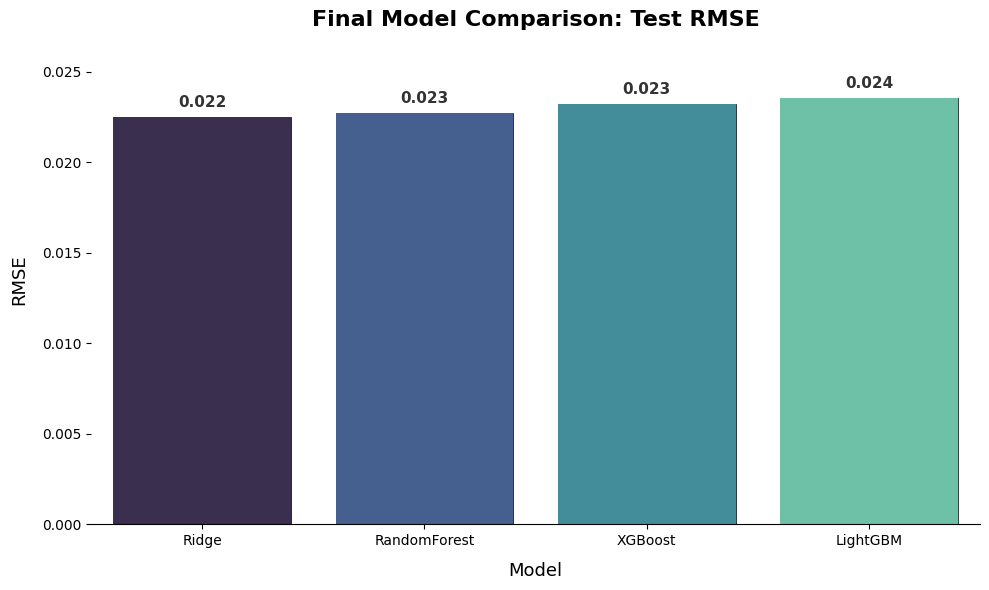

Saving best models to disk...
Saved optimized Ridge to ../models/ridge.pkl
Saved optimized RandomForest to ../models/randomforest.pkl
Saved optimized XGBoost to ../models/xgboost.pkl
Saved optimized LightGBM to ../models/lightgbm.pkl
Optimization, evaluation, and saving complete!


In [7]:
# Plot the Test RMSE comparison
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=results_df.index, 
    y=results_df['Test_RMSE'], 
    palette='mako',
    edgecolor='black',
    linewidth=0.5
)
for container in ax.containers:
    ax.bar_label(
        container, 
        fmt='%.3f',
        padding=5,
        fontsize=11,
        fontweight='bold',
        color='#333333'
    )
sns.barplot(x=results_df.index, y=results_df['Test_RMSE'], palette='mako')
plt.title('Final Model Comparison: Test RMSE', fontsize=16, fontweight='bold')
plt.ylabel('RMSE', fontsize=13, labelpad=10)
plt.xlabel('Model', fontsize=13, labelpad=10)
max_val = results_df['Test_RMSE'].max()
plt.ylim(0, max_val * 1.15)
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

# Save the optimized models
print("Saving best models to disk...")
for name, model in best_models.items():
    model_path = os.path.join(MODELS_DIR, f"{name.lower()}.pkl")
    joblib.dump(model, model_path)
    print(f"Saved optimized {name} to {model_path}")

print("Optimization, evaluation, and saving complete!")